## Loading and Preprocessing Data

In [1]:
import tensorflow as tf
import keras

#### The Data API

In [3]:
X =  tf.range(10)
dataset  = tf.data.Dataset.from_tensor_slices(X)
dataset

<_TensorSliceDataset element_spec=TensorSpec(shape=(), dtype=tf.int32, name=None)>

In [4]:
for item in dataset : 
    print(item)

tf.Tensor(0, shape=(), dtype=int32)
tf.Tensor(1, shape=(), dtype=int32)
tf.Tensor(2, shape=(), dtype=int32)
tf.Tensor(3, shape=(), dtype=int32)
tf.Tensor(4, shape=(), dtype=int32)
tf.Tensor(5, shape=(), dtype=int32)
tf.Tensor(6, shape=(), dtype=int32)
tf.Tensor(7, shape=(), dtype=int32)
tf.Tensor(8, shape=(), dtype=int32)
tf.Tensor(9, shape=(), dtype=int32)


#### Chaining Transformations

In [5]:
dataset = dataset.repeat(3).batch(7)
for item in dataset:
    print(item)

tf.Tensor([0 1 2 3 4 5 6], shape=(7,), dtype=int32)
tf.Tensor([7 8 9 0 1 2 3], shape=(7,), dtype=int32)
tf.Tensor([4 5 6 7 8 9 0], shape=(7,), dtype=int32)
tf.Tensor([1 2 3 4 5 6 7], shape=(7,), dtype=int32)
tf.Tensor([8 9], shape=(2,), dtype=int32)


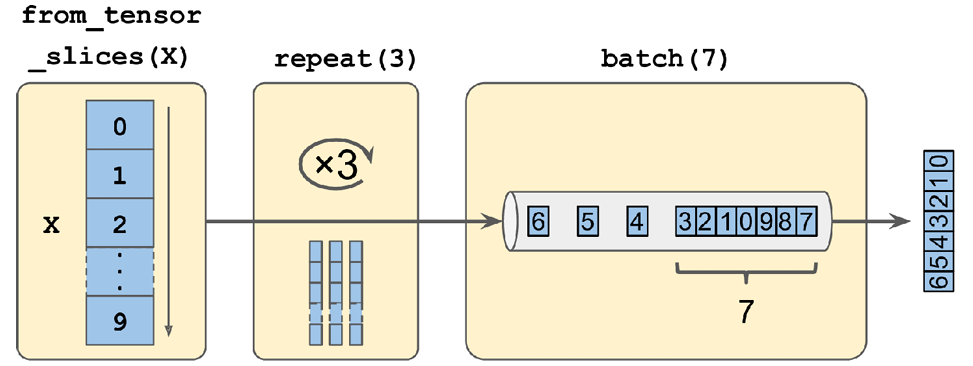

In [7]:
#you can also tranform the items by calling the map method

dataset = dataset.map(lambda x: x * 2)

In [10]:
# Applie unbatch fuction to split the batches into individual items
dataset = dataset.apply(tf.data.experimental.unbatch())

Instructions for updating:
Use `tf.data.Dataset.unbatch()`.


In [13]:
#Is also possible to siply filter the dataset using the filter() method
dataset = dataset.filter(lambda x: x < 10)

 # Look at just a few items from a dataset 
for item in dataset.take(5):
     print(item)    

tf.Tensor(0, shape=(), dtype=int32)
tf.Tensor(2, shape=(), dtype=int32)
tf.Tensor(4, shape=(), dtype=int32)
tf.Tensor(6, shape=(), dtype=int32)
tf.Tensor(8, shape=(), dtype=int32)


#### Shuffling the Data

In [14]:
dataset = tf.data.Dataset.range(10).repeat(3)
dataset = dataset.shuffle(buffer_size=5, seed=42).batch(7)
for item in dataset:
    print(item)

tf.Tensor([0 2 3 6 7 9 4], shape=(7,), dtype=int64)
tf.Tensor([5 0 1 1 8 6 5], shape=(7,), dtype=int64)
tf.Tensor([4 8 7 1 2 3 0], shape=(7,), dtype=int64)
tf.Tensor([5 4 2 7 8 9 9], shape=(7,), dtype=int64)
tf.Tensor([3 6], shape=(2,), dtype=int64)


### Interleaving lines from multiples files

In [15]:
import os
from pathlib import Path
import tensorflow as tf

# Example: interleaving lines from multiple text files using tf.data

# Create sample text files
data_dir = Path("sample_texts")
data_dir.mkdir(exist_ok=True)
files = []
contents = {
    "file_a.txt": ["A1", "A2", "A3", "A4"],
    "file_b.txt": ["B1", "B2", "B3", "B4"],
    "file_c.txt": ["C1", "C2", "C3", "C4"],
}
for name, lines in contents.items():
    path = data_dir / name
    path.write_text("\n".join(lines))
    files.append(str(path))

# Build a dataset of filenames
filenames_ds = tf.data.Dataset.from_tensor_slices(files)

# Interleave lines from files. We attach the filename to each line for clarity.
def read_with_name(filepath):
    filename = tf.strings.regex_replace(filepath, r".*/", "")  # keep basename
    return tf.data.TextLineDataset(filepath).map(
        lambda line: tf.strings.join([filename, b": ", line])
    )

# cycle_length controls how many files are read concurrently; block_length controls
# how many consecutive records to take from each file before moving to the next.
interleaved_ds = filenames_ds.interleave(
    read_with_name,
    cycle_length=3,
    block_length=1,
    num_parallel_calls=tf.data.AUTOTUNE,
)

# Inspect the interleaved output
for i, item in enumerate(interleaved_ds.take(12)):
    print(item.numpy().decode("utf-8"))

sample_texts\file_a.txt: A1
sample_texts\file_b.txt: B1
sample_texts\file_c.txt: C1
sample_texts\file_a.txt: A2
sample_texts\file_b.txt: B2
sample_texts\file_c.txt: C2
sample_texts\file_a.txt: A3
sample_texts\file_b.txt: B3
sample_texts\file_c.txt: C3
sample_texts\file_a.txt: A4
sample_texts\file_b.txt: B4
sample_texts\file_c.txt: C4


In [16]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import math

# Example: Interleaving lines from multiple CSV files containing the California housing dataset
# (This cell assumes `tf` and `Path` are already available in the notebook environment.)


# Load the California housing dataset and create a DataFrame
cal = fetch_california_housing()
df = pd.DataFrame(cal.data, columns=cal.feature_names)
df['MedHouseVal'] = cal.target  # target column

# Split into multiple CSV files
out_dir = Path("california_housing_files")
out_dir.mkdir(exist_ok=True)
n_files = 4
rows_per_file = math.ceil(len(df) / n_files)
housing_files = []
for i in range(n_files):
    chunk = df.iloc[i * rows_per_file : (i + 1) * rows_per_file]
    p = out_dir / f"part_{i}.csv"
    chunk.to_csv(p, index=False)
    housing_files.append(str(p))

# Build a filenames dataset and interleave parsed CSV lines from the files
filenames_ds = tf.data.Dataset.from_tensor_slices(housing_files)

num_columns = len(cal.feature_names) + 1  # features + target

def parse_line(line):
    # record_defaults: float defaults for each column
    record_defaults = [0.0] * num_columns
    fields = tf.io.decode_csv(line, record_defaults)
    features = tf.stack(fields[:-1])      # feature vector
    label = fields[-1]                    # target
    return features, label

def read_and_parse(filepath):
    return tf.data.TextLineDataset(filepath).skip(1).map(parse_line)

interleaved_ds = filenames_ds.interleave(
    read_and_parse,
    cycle_length=4,
    block_length=1,
    num_parallel_calls=tf.data.AUTOTUNE,
)

# Inspect a few interleaved examples
for idx, (features, label) in enumerate(interleaved_ds.take(6)):
    print(f"Example {idx}: features shape = {features.shape}, label = {label.numpy():.3f}")

Example 0: features shape = (8,), label = 4.526
Example 1: features shape = (8,), label = 0.914
Example 2: features shape = (8,), label = 3.356
Example 3: features shape = (8,), label = 1.932
Example 4: features shape = (8,), label = 3.585
Example 5: features shape = (8,), label = 0.993


### Preprocessing the Data

In [ ]:
# X_mean , X_std  = [.....]     
# n_inputs = 8 

def preprocess(line):

    defs=[0.0] * n_inputs +[tf.constant([0.0], dtype=tf.float32)]
    fields = tf.io.decode_csv(line, record_defaults=defs)
    X = tf.stack(fields[:-1])
    y = tf.stack(fields[-1:])
    return (X - X_mean) / X_std, y


##### Putting everything together
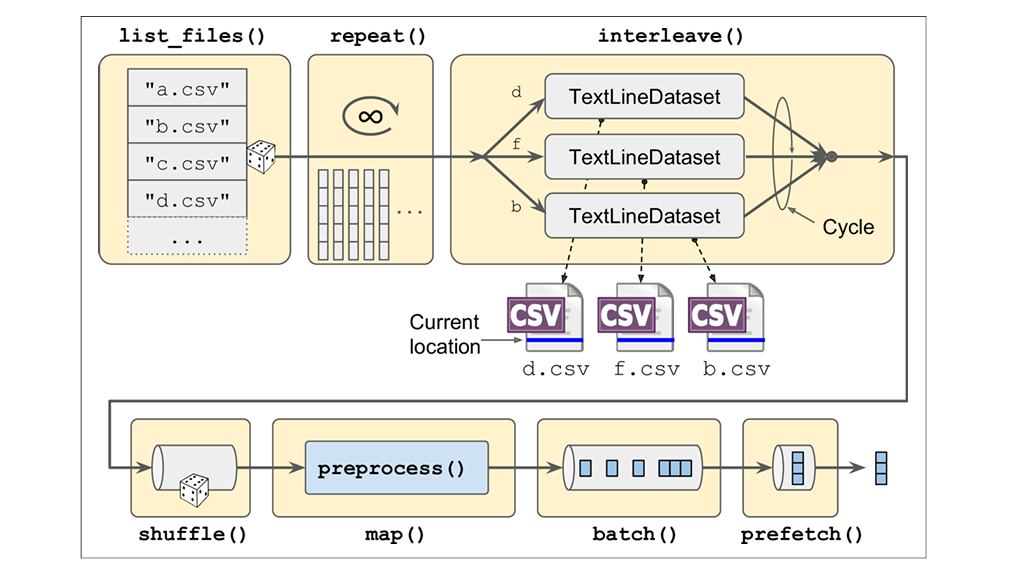

In [ ]:
def csv_reader(filepath,repeat=1,n_readers=5,n_read_threads=None,shuffle_buffer_size=10000,
               n_parse_threads=5,batch_size=32):
    dataset = tf.data.TextLineDataset(filepath)  # skip header
    dataset = dataset.interleave(
        lambda filepath: tf.data.TextLineDataset(filepath).skip(1) , cycle_length=n_readers, num_parallel_calls=n_read_threads
    )
    dataset = dataset.batch(batch_size).repeat(repeat)
    return dataset

### Prefetching
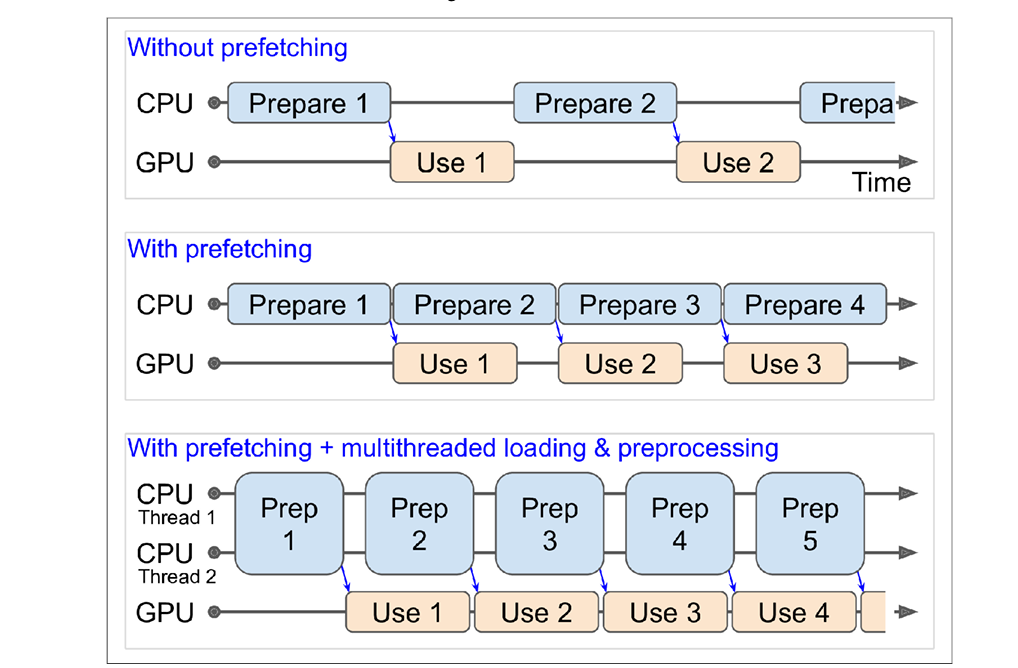

### Compressed TFRecord Files

In [ ]:
options = tf.io.TFRecordOptions(compression_type='GZIP')
with tf.io.TFRecordWriter('my_compressed-tfrecord',options) as f :
    for i in range(10):
        example = tf.train.Example(features=tf.train.Features(feature={
            'feature': tf.train.Feature(float_list=tf.train.FloatList(value=[float(i)]))
        }))
        f.write(example.SerializeToString())

dataset = tf.data.RecordBatchDataset('my_compressed-tfrecord', compression_type='GZIP')        

In [ ]:
# Example: create, write, read and inspect TensorFlow protobufs (tf.train.Example / TFRecord)

tfrecord_path = "protobuf_example.tfrecord"

def _bytes_feature(value):
    return tf.train.Feature(bytes_list=tf.train.BytesList(value=[value.encode() if isinstance(value, str) else value]))

def _float_feature(value):
    return tf.train.Feature(float_list=tf.train.FloatList(value=[float(value)]))

def _int64_feature(value):
    return tf.train.Feature(int64_list=tf.train.Int64List(value=[int(value)]))

# Create and write Example protos
examples = [
    {"id": 1, "value": 3.14, "text": "hello"},
    {"id": 2, "value": 2.71, "text": "world"},
    {"id": 3, "value": 1.41, "text": "tf-proto"},
]

with tf.io.TFRecordWriter(tfrecord_path) as writer:
    for ex in examples:
        proto = tf.train.Example(features=tf.train.Features(feature={
            "id": _int64_feature(ex["id"]),
            "value": _float_feature(ex["value"]),
            "text": _bytes_feature(ex["text"]),
        }))
        writer.write(proto.SerializeToString())

# Read back with TFRecordDataset and parse via feature spec
feature_spec = {
    "id": tf.io.FixedLenFeature([], tf.int64),
    "value": tf.io.FixedLenFeature([], tf.float32),
    "text": tf.io.FixedLenFeature([], tf.string),
}

ds = tf.data.TFRecordDataset([tfrecord_path])
for raw in ds.take(3):
    parsed = tf.io.parse_single_example(raw, feature_spec)
    print("Parsed:", {k: parsed[k].numpy() for k in parsed})

    # Direct protobuf-level inspection
    proto = tf.train.Example.FromString(raw.numpy())
    text_val = proto.features.feature["text"].bytes_list.value[0].decode()
    print("Protobuf text field:", text_val)

### Preprocessing the imput Features

In [ ]:
#use a lambda  layer to preprocess the data on the fly


means = np.mean(X_train,axis= 0)
stds = np.std(X_train,axis= 0)
eps = keras.backend.epsilon()
model = keras.models.Sequential([

    keras.layers.Lambda(lambda x: (x - means) / (stds + eps)),
    #[....]  other layers
])


#or you can also create a custom preprocessing layer by subclassing the Layer class
class StandardizationLayer(keras.layers.Layer):
    def __init__(self, means, stds, **kwargs):
        super().__init__(**kwargs)
        self.means = tf.constant(means, dtype=tf.float32)
        self.stds = tf.constant(stds, dtype=tf.float32)

    def call(self, inputs):
        return (inputs - self.means) / (self.stds + keras.backend.epsilon())
    
std_layer = StandardizationLayer(means, stds)
model = keras.models.Sequential([
    std_layer,
    #[....]  other layers
])


Enconding using One Hot Vectors

In [ ]:
vocab = ['<1H OCEAN' , 'INLAND' , 'NEAR OCEAN' , 'NEAR BAY' , 'ISLAND']
indices = tf.range(len(vocab) , dtype=tf.int64)
table_init = tf.lookup.KeyValueTensorInitializer(vocab, indices)
num_ovv_buckets = 2
tables = tf.lookup.StaticVocabularyTable(table_init, num_ovv_buckets)


#use the lookup table to encode a small batch of categorical features 

categories  = tf.constant(['NEAR BAY' , 'DESERT' , 'INLAND' , 'INLAND'])
cat_indices = tables.lookup(categories)
cat_indices 


cat_one_hot = tf.one_hot(cat_indices , depth=len(vocab) + num_ovv_buckets)
cat_one_hot

#### Encoding Categorical Features Using Embeddigns

In [ ]:

#create a embeddING matrix 
from matplotlib import table


embedding_dim = 2
embed_init = tf.random.uniform([len(vocab) + num_oov_buckets, embedding_dim])
embedding_matrix = tf.Variable(embed_init)
#encode the same batch of categorical features  

categories = tf.constant(['NEAR BAY' , 'DESERT' , 'INLAND' , 'INLAND'])

cat_indice = table.lookup(categories)
tf.nn.embedding_lookup(embedding_matrix , cat_indices)

#keras provide a keras.layers embedding layer that handles the embedding matrix
#called the some categorys indices it return the rows
embedding_layer = keras.layers.Embedding(input_dim=len(vocab) + num_oov_buckets, output_dim=embedding_dim, embeddings_initializer=tf.random_uniform_initializer())
embedding_layer(cat_indices)

#Now create a Keras Model that can process categorical features by combining the lookup table and the embedding layer

regular_inputs = keras.layers.Input(shape=(8,), name='regular_inputs')
categories = keras.layers.Input(shape=(), dtype=tf.string, name='category_inputs')
cat_indices = keras.layers.Lambda(lambda x: tables.lookup(x))(categories)
cat_embed=keras.layers.Embedding(input_dim=6,output_dim = 2)(cat_indices)
encodes_inputs = keras.layers.Concatenate()([regular_inputs, cat_embed])
outputs = keras.layers.Dense(1)(encodes_inputs)
model = keras.Model(inputs=[regular_inputs, categories], outputs=outputs)


_IncompleteInputError: incomplete input (3171476505.py, line 6)

### Keras Preprocessing Layers

In [ ]:
normalization = keras.layers.Normalization()
discretization = keras.layers.Discretization([...])
pipeline = keras.layers.PreprocessingStage([normalization, discretization])
pipeline.adapt(data_sample)

### TF Transform

In [ ]:
import tensorflow_transform as tft

def preprocess(inputs) :
    median_age = inputs['housing_median_age']
    ocean_proximity = inputs['ocean_proximity']
    standardixed_age =tft.scale_to_z_score(median_age)
    #tft.compute_and_apply_vocabulary() will compute the vocabulary of the ocean_proximity feature and map each category to an integer index
    ocean_proximity_indices = tft.compute_and_apply_vocabulary(ocean_proximity) 
    return standardixed_age, ocean_proximity_indices

### The TensorFlow Datasets 

In [ ]:
import tensorflow_datasets as tfds
dataset = tfds.load(name='mnist')
mnist_train , mnist_test = dataset['train'], dataset['test']

#You can then aplly any tranformation

mnist_train = mnist_train.shuffle(10000).batch(32).map(lambda x: (tf.cast(x['image'], tf.float32) / 255.0, x['label'])).prefetch(tf.data.AUTOTUNE)

In [ ]:
dataset = tfds.load(name="mnist", batch_size=32, as_supervised=True)
mnist_train = dataset["train"].prefetch(1)
model = keras.models.Sequential([...])
model.compile(loss="sparse_categorical_crossentropy", optimizer="sgd")
model.fit(mnist_train, epochs=5)